In [1]:
from pathlib import Path

PROJECT_ROOT = Path("..")
MODEL_RESULTS = PROJECT_ROOT / "model_results"
GENERATED_RESULTS = PROJECT_ROOT / "generated_results"
GENERATED_RESULTS.mkdir(exist_ok=True)

In [2]:
# Auto-discover classifiers and common datasets from disk
classifiers = sorted(p.name for p in MODEL_RESULTS.iterdir() if p.is_dir())
print("Classifiers found:", classifiers)

# dataset_sets = [
#     set(p.name for p in (MODEL_RESULTS / c / "Predictions").iterdir() if p.is_dir())
#     for c in classifiers
# ]
# datasets = sorted(set.intersection(*dataset_sets))
from aeon.datasets.tsc_datasets import univariate_equal_length

datasets = univariate_equal_length
print(f"Common datasets: {len(datasets)}")

# Detect available resamples from any classifier/dataset combo
sample_files = list((MODEL_RESULTS / classifiers[0] / "Predictions" / datasets[0]).glob("testResample*.csv"))
resamples = sorted(int(f.stem.replace("testResample", "")) for f in sample_files)
print(f"Resamples: {resamples}")

Classifiers found: ['Catch22', 'HIVECOTEV2', 'MiniRocket', 'MultiRocketHydra', 'ROCKET', 'TSCGlue-Accuracy-GPU', 'TSCGlue-LogLoss-GPU', 'TSCGlue-ROCAUC-GPU']
Common datasets: 112
Resamples: [0, 1, 4]


In [3]:
classifiers.remove('HIVECOTEV2')

# Count missing combinations (classifier x dataset x resample)
total = len(classifiers) * len(datasets) * len(resamples)
print(total, len(classifiers), len(datasets), len(resamples))
missing = 0
missing_list = []
for c in classifiers:
    for d in datasets:
        for r in resamples:
            path = MODEL_RESULTS / c / "Predictions" / d / f"testResample{r}.csv"
            if not path.exists():
                missing += 1
                missing_list.append((c, d, r))

print(f"Total combinations : {total}")
print(f"Present            : {total - missing}")
print(f"Missing            : {missing}")
if missing_list:
    print("\nFirst 20 missing:")
    for c, d, r in missing_list[:20]:
        print(f"  {c} / {d} / resample {r}")

2352 7 112 3
Total combinations : 2352
Present            : 2032
Missing            : 320

First 20 missing:
  TSCGlue-Accuracy-GPU / ACSF1 / resample 0
  TSCGlue-Accuracy-GPU / ACSF1 / resample 1
  TSCGlue-Accuracy-GPU / Adiac / resample 1
  TSCGlue-Accuracy-GPU / ArrowHead / resample 4
  TSCGlue-Accuracy-GPU / Beef / resample 0
  TSCGlue-Accuracy-GPU / Beef / resample 4
  TSCGlue-Accuracy-GPU / BeetleFly / resample 0
  TSCGlue-Accuracy-GPU / BME / resample 4
  TSCGlue-Accuracy-GPU / Car / resample 1
  TSCGlue-Accuracy-GPU / Chinatown / resample 4
  TSCGlue-Accuracy-GPU / ChlorineConcentration / resample 1
  TSCGlue-Accuracy-GPU / ChlorineConcentration / resample 4
  TSCGlue-Accuracy-GPU / CinCECGTorso / resample 4
  TSCGlue-Accuracy-GPU / Coffee / resample 4
  TSCGlue-Accuracy-GPU / Computers / resample 1
  TSCGlue-Accuracy-GPU / CricketX / resample 0
  TSCGlue-Accuracy-GPU / CricketY / resample 0
  TSCGlue-Accuracy-GPU / Crop / resample 0
  TSCGlue-Accuracy-GPU / DiatomSizeReduction

In [4]:
from tsml_eval.evaluation import evaluate_classifiers_by_problem

evaluate_classifiers_by_problem(
    str(MODEL_RESULTS),
    classifiers,
    datasets,
    str(GENERATED_RESULTS),
    resamples=resamples,
    error_on_missing=False,
    eval_name="tscbench",
    verbose=True,
)

Loaded Catch22 on ACSF1 test resample 0.
Loaded Catch22 on ACSF1 test resample 1.
Loaded Catch22 on ACSF1 test resample 4.
Loaded Catch22 on Adiac test resample 0.
Loaded Catch22 on Adiac test resample 1.
Loaded Catch22 on Adiac test resample 4.
Loaded Catch22 on ArrowHead test resample 0.
Loaded Catch22 on ArrowHead test resample 1.
Loaded Catch22 on ArrowHead test resample 4.
Loaded Catch22 on Beef test resample 0.
Loaded Catch22 on Beef test resample 1.
Loaded Catch22 on Beef test resample 4.
Loaded Catch22 on BeetleFly test resample 0.
Loaded Catch22 on BeetleFly test resample 1.
Loaded Catch22 on BeetleFly test resample 4.
Loaded Catch22 on BirdChicken test resample 0.
Loaded Catch22 on BirdChicken test resample 1.
Loaded Catch22 on BirdChicken test resample 4.
Loaded Catch22 on BME test resample 0.
Loaded Catch22 on BME test resample 1.
Loaded Catch22 on BME test resample 4.
Loaded Catch22 on Car test resample 0.
Loaded Catch22 on Car test resample 1.
Loaded Catch22 on Car test r

/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/tsml_eval/evaluation/multiple_estimator_evaluation.py:1249: UserWarning: Estimators MultiRocketHydra and TSCGlue-LogLoss-GPU have the same performanceon all datasets. This may cause problems when forming cliques.
  p_values = wilcoxon_test(average_stats, estimators, lower_better=not higher_better)
/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/tsml_eval/evaluation/multiple_estimator_evaluation.py:1166: UserWarning: Error during figure creation for Accuracy: each sample in `data` must contain two or more observations along `axis`.
  average, rank = _create_directory_for_statistic(
/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/tsml_eval/evaluation/multiple_estimator_evaluation.py:1281: UserWarning: This figu

In [5]:
# Display all generated figures inline
from IPython.display import display, Image

for fig_path in sorted(GENERATED_RESULTS.rglob("*.pdf")):
    print(fig_path.relative_to(PROJECT_ROOT))

for fig_path in sorted(GENERATED_RESULTS.rglob("*.png")):
    print(fig_path.relative_to(PROJECT_ROOT))
    display(Image(filename=str(fig_path)))

generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_MiniRocket.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_MultiRocketHydra.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_ROCKET.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_TSCGlue-Accuracy-GPU.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_TSCGlue-LogLoss-GPU.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_TSCGlue-ROCAUC-GPU.pdf
generated_results/tscbench/AUROC/figures/scatters/MiniRocket/tscbench_auroc_scatter_MiniRocket_Catch22.pdf
generated_results/tscbench/AUROC/figures/scatters/MiniRocket/tscbench_auroc_scatter_MiniRocket_MultiRocketHydra.pdf
generated_results/tscbench/AUROC/figures/scatters/MiniRocket/tscbench_auroc_scatter_MiniRocket_ROCKET.pdf
generated_results/

In [6]:
import pandas as pd

for csv_path in sorted(GENERATED_RESULTS.glob("**/*summary*.csv")):
    print(csv_path.name)
    display(pd.read_csv(csv_path, index_col=0))

tscbench_summary.csv


,TSCGlue-Accuracy-GPU,TSCGlue-ROCAUC-GPU,MultiRocketHydra,TSCGlue-LogLoss-GPU,MiniRocket,ROCKET,Catch22
testAccuracy,,,,,,,
testAccuracyMean,0.9343333333333333,0.9322222222222223,0.930888888888889,0.930888888888889,0.9128888888888889,0.9115555555555556,0.7982222222222223
testAccuracyAvgRank,1.0,2.0,3.5,3.5,5.0,6.0,7.0
testBalAcc,TSCGlue-Accuracy-GPU,TSCGlue-ROCAUC-GPU,TSCGlue-LogLoss-GPU,MultiRocketHydra,MiniRocket,ROCKET,Catch22
testBalAccMean,0.9333203338528658,0.9315887822077764,0.9304557576158269,0.9296909771841994,0.9117582459963313,0.910242831188568,0.7948002971565088
testBalAccAvgRank,1.0,2.0,3.0,4.0,5.0,6.0,7.0
testAUROC,TSCGlue-LogLoss-GPU,TSCGlue-ROCAUC-GPU,TSCGlue-Accuracy-GPU,MultiRocketHydra,MiniRocket,ROCKET,Catch22
testAUROCMean,0.9795959529177579,0.9790899708487023,0.9372723694925869,0.9296909771841992,0.9117582459963313,0.910242831188568,0.8853621531666391
testAUROCAvgRank,1.0,2.0,3.0,4.0,5.0,6.0,7.0
testLogLoss,TSCGlue-LogLoss-GPU,TSCGlue-ROCAUC-GPU,Catch22,TSCGlue-Accuracy-GPU,MultiRocketHydra,MiniRocket,ROCKET


tscbench_summary_table.csv


,Catch22,MiniRocket,MultiRocketHydra,ROCKET,TSCGlue-Accuracy-GPU,TSCGlue-LogLoss-GPU,TSCGlue-ROCAUC-GPU
testAccuracyMean,0.798222,9.128889e-01,9.308889e-01,9.115556e-01,9.343333e-01,9.308889e-01,9.322222e-01
testBalAccMean,0.794800,9.117582e-01,9.296910e-01,9.102428e-01,9.333203e-01,9.304558e-01,9.315888e-01
testAUROCMean,0.885362,9.117582e-01,9.296910e-01,9.102428e-01,9.372724e-01,9.795960e-01,9.790900e-01
testLogLossMean,0.453622,3.139803e+00,2.491017e+00,3.187861e+00,2.208167e+00,1.908126e-01,2.017669e-01
testSensitivityMean,0.746829,8.959081e-01,9.128978e-01,8.918402e-01,9.191194e-01,9.243838e-01,9.227088e-01
testSpecificityMean,0.842771,9.276084e-01,9.464841e-01,9.286455e-01,9.475213e-01,9.365277e-01,9.404688e-01
testF1Mean,0.774354,9.052148e-01,9.246230e-01,9.035490e-01,9.285703e-01,9.254924e-01,9.266782e-01
testFitTimeMean,903.000000,3.413333e+02,2.015333e+03,1.907333e+03,2.683300e+04,2.763133e+04,2.746267e+04
testPredictTimeMean,3030.333333,4.620000e+02,9.816333e+03,1.514400e+04,1.551423e+05,1.304777e+05,1.788870e+05
testMemoryUsageMean,46421.333333,5.023061e+06,5.485909e+06,1.807701e+07,1.044739e+08,8.963823e+07,8.697993e+07


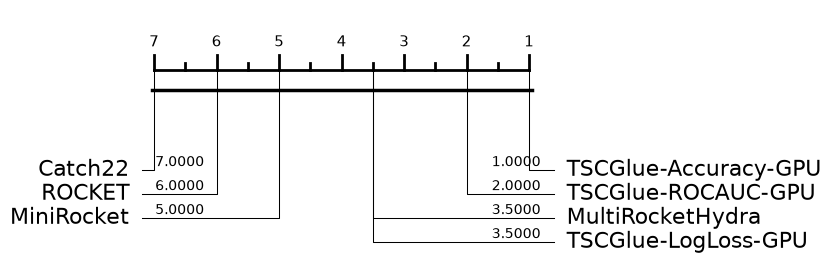

/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


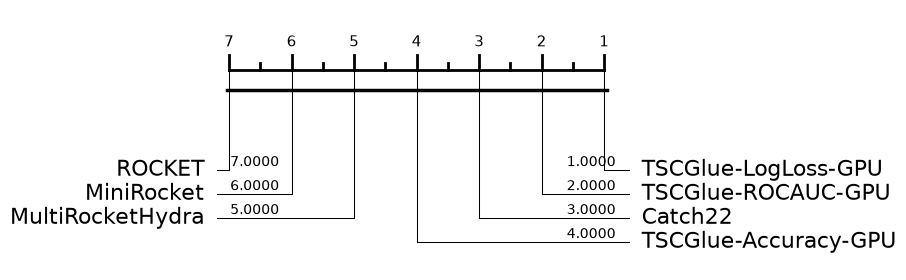

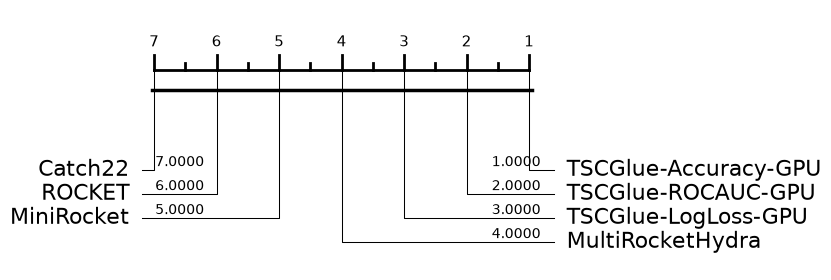

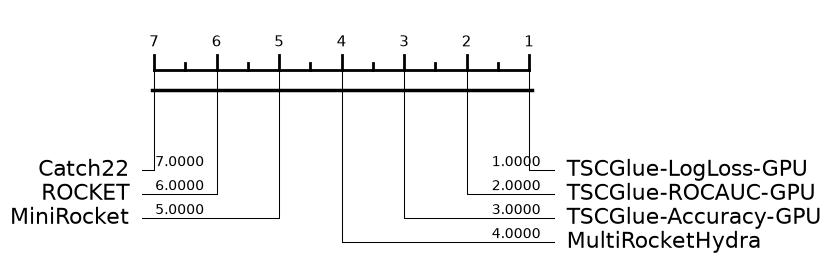

In [7]:
import pickle
import matplotlib.pyplot as plt

for label, subdir, metric in [
    ("Accuracy", "Accuracy", "accuracy"),
    ("LogLoss", "LogLoss", "logloss"),
    ("F1", "F1", "f1"),
    ("ROCAUC", "AUROC", "auroc"),
]:
    pkl_path = GENERATED_RESULTS / "tscbench" / subdir / "figures" / f"tscbench_{metric}_critical_difference.pickle"
    with open(pkl_path, "rb") as f:
        fig = pickle.load(f)
    plt.show()